In [111]:
# Section 1 — Load race data (2024 Bahrain GP)

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

fastf1.Cache.enable_cache('/Users/Akshithreddy/Desktop/f1/cache')

session = fastf1.get_session(2024, 'Bahrain', 'R')
session.load()

print("Session loaded:", session.event['EventName'], session.date)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Session loaded: Bahrain Grand Prix 2024-03-02 15:00:00


In [112]:
# Section 2 — Extract stint data + tyre compounds

laps = session.laps.copy()

# Keep only the columns we need
cols = ['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'PitInTime', 'PitOutTime']
laps = laps[cols].copy()

# Convert LapTime to seconds (it comes in as timedelta)
laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()

# Drop outliers — laps > 120s are almost always safety car / pit laps
laps = laps[laps['LapTimeSec'].between(75, 120)]

# Drop nulls
laps = laps.dropna(subset=['LapTimeSec', 'Compound', 'TyreLife'])

# Preview
print(f"Total clean laps: {len(laps)}")
print(laps[['Driver','LapNumber','Compound','TyreLife','LapTimeSec']].head(10))

Total clean laps: 1121
  Driver  LapNumber Compound  TyreLife  LapTimeSec
0    VER        1.0     SOFT       4.0      97.284
1    VER        2.0     SOFT       5.0      96.296
2    VER        3.0     SOFT       6.0      96.753
3    VER        4.0     SOFT       7.0      96.647
4    VER        5.0     SOFT       8.0      97.173
5    VER        6.0     SOFT       9.0      97.092
6    VER        7.0     SOFT      10.0      97.038
7    VER        8.0     SOFT      11.0      97.024
8    VER        9.0     SOFT      12.0      97.229
9    VER       10.0     SOFT      13.0      96.960


In [113]:
# Section 3 — Tyre degradation model (Bahrain 2024)
# Bahrain is a high-degradation track. Pirelli nominated C1/C2/C3
# (Hard/Medium/Soft in race nomenclature).
# Values grounded in Pirelli pre-event notes + 2024 race reports.

degradation_models = {
    'SOFT': {
        'base_time': 96.5,       # Fastest compound at Bahrain
        'deg_per_lap': 0.250     # High deg — usually only used lap 1 or short stint
    },
    'MEDIUM': {
        'base_time': 97.4,       # ~0.9s slower base than Soft
        'deg_per_lap': 0.145     # Moderate degradation
    },
    'HARD': {
        'base_time': 98.2,       # Slowest base but most consistent
        'deg_per_lap': 0.075     # Low degradation — built for long stints
    }
}

print("Degradation models (Bahrain 2024):\n")
for compound, m in degradation_models.items():
    t1  = m['base_time'] + m['deg_per_lap'] * 1
    t15 = m['base_time'] + m['deg_per_lap'] * 15
    t30 = m['base_time'] + m['deg_per_lap'] * 30
    print(f"  {compound}: lap 1 = {t1:.3f}s | lap 15 = {t15:.3f}s | lap 30 = {t30:.3f}s")

Degradation models (Bahrain 2024):

  SOFT: lap 1 = 96.750s | lap 15 = 100.250s | lap 30 = 104.000s
  MEDIUM: lap 1 = 97.545s | lap 15 = 99.575s | lap 30 = 101.750s
  HARD: lap 1 = 98.275s | lap 15 = 99.325s | lap 30 = 100.450s


In [114]:
# Section 4 — Undercut / Overcut Simulator

def simulate_strategy(
    driver_a_compound, driver_a_tyre_age,
    driver_b_compound, driver_b_tyre_age,
    gap_ab,
    pit_lap,
    total_laps,
    new_compound,
    pit_loss=24.0        # Bahrain avg pit loss ~24s
):
    model_a   = degradation_models[driver_a_compound]
    model_b   = degradation_models[driver_b_compound]
    model_new = degradation_models[new_compound]

    results = []
    current_gap        = gap_ab
    a_tyre_age         = driver_a_tyre_age
    b_tyre_age         = driver_b_tyre_age
    pitted             = False
    compound_a_current = driver_a_compound

    for lap in range(1, total_laps + 1):

        # Driver A
        if lap == pit_lap and not pitted:
            lap_time_a = model_a['base_time'] + model_a['deg_per_lap'] * a_tyre_age + pit_loss
            a_tyre_age = 1
            pitted = True
            compound_a_current = new_compound
        elif pitted:
            lap_time_a = model_new['base_time'] + model_new['deg_per_lap'] * a_tyre_age
            a_tyre_age += 1
        else:
            lap_time_a = model_a['base_time'] + model_a['deg_per_lap'] * a_tyre_age
            a_tyre_age += 1

        # Driver B stays out
        lap_time_b = model_b['base_time'] + model_b['deg_per_lap'] * b_tyre_age
        b_tyre_age += 1

        current_gap += (lap_time_b - lap_time_a)

        results.append({
            'Lap': lap,
            'GapAheadOfB': round(current_gap, 3),
            'LapTimeA': round(lap_time_a, 3),
            'LapTimeB': round(lap_time_b, 3),
            'CompoundA': compound_a_current,
            'Pitted': lap == pit_lap
        })

    return pd.DataFrame(results)


# --- Bahrain 2024 scenario ---
# Verstappen (A) 3.0s ahead of Leclerc (B)
# Both on Medium, A on tyre lap 18, B on tyre lap 15
# 30 laps remaining
# Classic Bahrain undercut: pit early for Hard

result_undercut = simulate_strategy(
    driver_a_compound='MEDIUM', driver_a_tyre_age=18,
    driver_b_compound='MEDIUM', driver_b_tyre_age=15,
    gap_ab=3.0,
    pit_lap=3,
    total_laps=30,
    new_compound='HARD',
    pit_loss=24.0
)

result_overcut = simulate_strategy(
    driver_a_compound='MEDIUM', driver_a_tyre_age=18,
    driver_b_compound='MEDIUM', driver_b_tyre_age=15,
    gap_ab=3.0,
    pit_lap=8,
    total_laps=30,
    new_compound='HARD',
    pit_loss=24.0
)

print("=== UNDERCUT (pit lap 3) ===")
print(result_undercut[['Lap','GapAheadOfB','LapTimeA','LapTimeB','CompoundA','Pitted']].head(12))
print(f"\nFinal gap: {result_undercut['GapAheadOfB'].iloc[-1]:.2f}s")
print("Outcome:", "Undercut WORKED ✓" if result_undercut['GapAheadOfB'].iloc[-1] > 0 else "Undercut FAILED ✗")

print("\n=== OVERCUT (pit lap 8) ===")
print(result_overcut[['Lap','GapAheadOfB','LapTimeA','LapTimeB','CompoundA','Pitted']].head(12))
print(f"\nFinal gap: {result_overcut['GapAheadOfB'].iloc[-1]:.2f}s")
print("Outcome:", "Overcut WORKED ✓" if result_overcut['GapAheadOfB'].iloc[-1] > 0 else "Overcut FAILED ✗")

=== UNDERCUT (pit lap 3) ===
    Lap  GapAheadOfB  LapTimeA  LapTimeB CompoundA  Pitted
0     1        2.565   100.010    99.575    MEDIUM   False
1     2        2.130   100.155    99.720    MEDIUM   False
2     3      -22.305   124.300    99.865      HARD    True
3     4      -20.570    98.275   100.010      HARD   False
4     5      -18.765    98.350   100.155      HARD   False
5     6      -16.890    98.425   100.300      HARD   False
6     7      -14.945    98.500   100.445      HARD   False
7     8      -12.930    98.575   100.590      HARD   False
8     9      -10.845    98.650   100.735      HARD   False
9    10       -8.690    98.725   100.880      HARD   False
10   11       -6.465    98.800   101.025      HARD   False
11   12       -4.170    98.875   101.170      HARD   False

Final gap: 49.11s
Outcome: Undercut WORKED ✓

=== OVERCUT (pit lap 8) ===
    Lap  GapAheadOfB  LapTimeA  LapTimeB CompoundA  Pitted
0     1        2.565   100.010    99.575    MEDIUM   False
1     2    

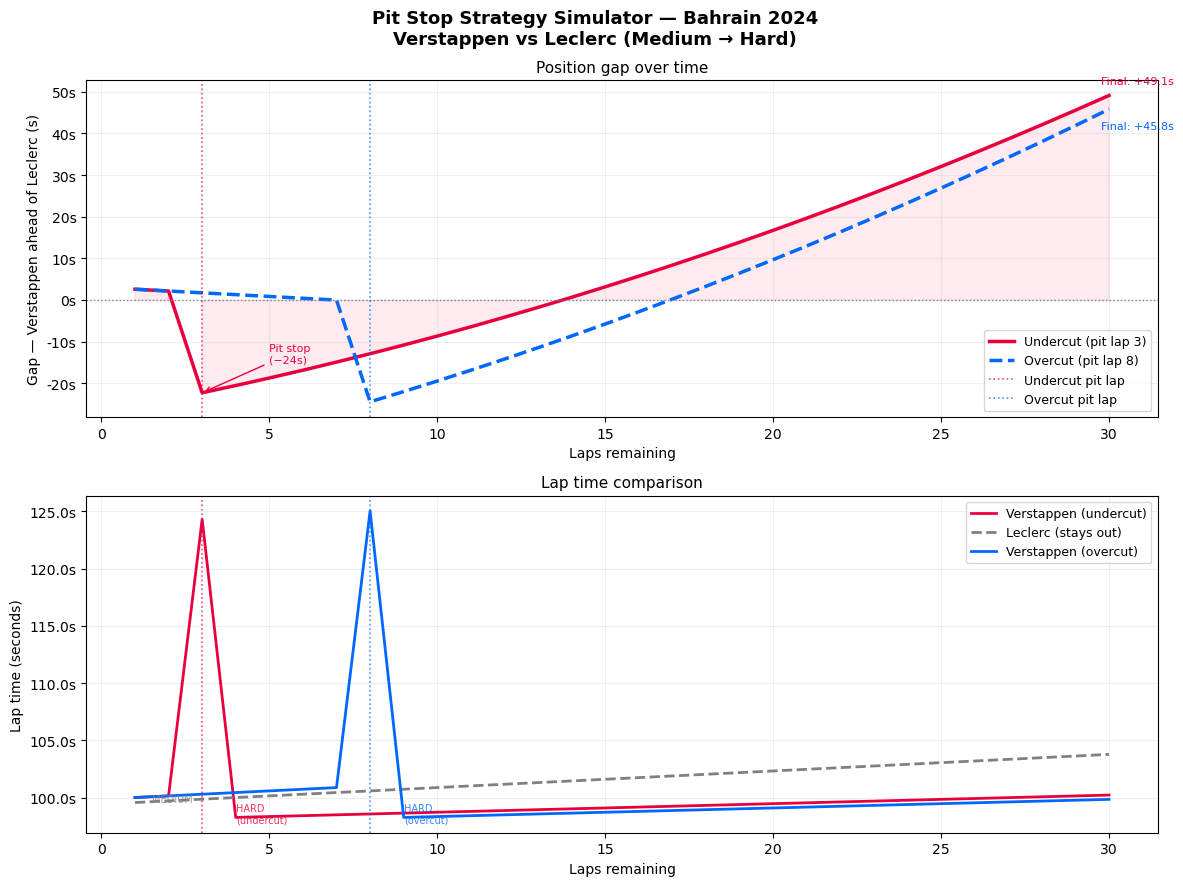

Plot saved to desktop.


In [115]:
# Section 5 — Visualisation

def plot_strategy(result_undercut, result_overcut):
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))
    fig.suptitle('Pit Stop Strategy Simulator — Bahrain 2024\nVerstappen vs Leclerc (Medium → Hard)', 
                 fontsize=13, fontweight='bold')

    # --- Plot 1: Gap over time ---
    ax1 = axes[0]

    ax1.plot(result_undercut['Lap'], result_undercut['GapAheadOfB'],
             color='#E8003D', linewidth=2.5, label='Undercut (pit lap 3)')
    ax1.plot(result_overcut['Lap'], result_overcut['GapAheadOfB'],
             color='#0067FF', linewidth=2.5, linestyle='--', label='Overcut (pit lap 8)')
    ax1.axhline(0, color='gray', linestyle=':', linewidth=1)

    # Shade positive region (A ahead)
    ax1.fill_between(result_undercut['Lap'], result_undercut['GapAheadOfB'], 0,
                     where=result_undercut['GapAheadOfB'] > 0,
                     alpha=0.08, color='#E8003D')
    ax1.fill_between(result_undercut['Lap'], result_undercut['GapAheadOfB'], 0,
                     where=result_undercut['GapAheadOfB'] < 0,
                     alpha=0.08, color='#E8003D')

    # Mark pit laps
    ax1.axvline(3, color='#E8003D', linestyle=':', linewidth=1.2, alpha=0.7, label='Undercut pit lap')
    ax1.axvline(8, color='#0067FF', linestyle=':', linewidth=1.2, alpha=0.7, label='Overcut pit lap')

    # Annotations
    ax1.annotate('Pit stop\n(−24s)', xy=(3, result_undercut.loc[2, 'GapAheadOfB']),
                 xytext=(5, -15), fontsize=8, color='#E8003D',
                 arrowprops=dict(arrowstyle='->', color='#E8003D', lw=1))
    ax1.annotate(f"Final: +{result_undercut['GapAheadOfB'].iloc[-1]:.1f}s",
                 xy=(result_undercut['Lap'].iloc[-1], result_undercut['GapAheadOfB'].iloc[-1]),
                 xytext=(-6, 8), textcoords='offset points', fontsize=8, color='#E8003D')
    ax1.annotate(f"Final: +{result_overcut['GapAheadOfB'].iloc[-1]:.1f}s",
                 xy=(result_overcut['Lap'].iloc[-1], result_overcut['GapAheadOfB'].iloc[-1]),
                 xytext=(-6, -14), textcoords='offset points', fontsize=8, color='#0067FF')

    ax1.set_xlabel('Laps remaining', fontsize=10)
    ax1.set_ylabel('Gap — Verstappen ahead of Leclerc (s)', fontsize=10)
    ax1.set_title('Position gap over time', fontsize=11)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.2)
    ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0fs'))

    # --- Plot 2: Lap times ---
    ax2 = axes[1]

    ax2.plot(result_undercut['Lap'], result_undercut['LapTimeA'],
             color='#E8003D', linewidth=2, label='Verstappen (undercut)')
    ax2.plot(result_undercut['Lap'], result_undercut['LapTimeB'],
             color='gray', linewidth=2, linestyle='--', label='Leclerc (stays out)')
    ax2.plot(result_overcut['Lap'], result_overcut['LapTimeA'],
             color='#0067FF', linewidth=2, label='Verstappen (overcut)')

    # Mark pit laps
    ax2.axvline(3, color='#E8003D', linestyle=':', linewidth=1.2, alpha=0.7)
    ax2.axvline(8, color='#0067FF', linestyle=':', linewidth=1.2, alpha=0.7)

    # Compound labels
    ax2.text(1.5, 99.6, 'MEDIUM', fontsize=7, color='gray', alpha=0.8)
    ax2.text(4,   97.8, 'HARD\n(undercut)', fontsize=7, color='#E8003D', alpha=0.8)
    ax2.text(9,   97.8, 'HARD\n(overcut)', fontsize=7, color='#0067FF', alpha=0.8)

    ax2.set_xlabel('Laps remaining', fontsize=10)
    ax2.set_ylabel('Lap time (seconds)', fontsize=10)
    ax2.set_title('Lap time comparison', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2)
    ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1fs'))

    plt.tight_layout()
    plt.savefig('/Users/Akshithreddy/Desktop/projects/f1/strategy_simulation.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved to desktop.")


plot_strategy(result_undercut, result_overcut)